<a href="https://colab.research.google.com/github/MuriloPuglia/My-Project/blob/main/Global_Solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projeto Ares-Prospector



---



## Introdução

O projeto Ares-Prospector tem como objetivo simular um rover autônomo capaz de analisar características do terreno por meio de sensores e prever a probabilidade de encontrar recursos de interesse para futuras missões espaciais.

Para isso, foram utilizados dados provenientes de sensores RGB e de distância, além de técnicas de Machine Learning para estimar o potencial de recursos em cada região analisada.

A solução busca demonstrar como Inteligência Artificial e análise de dados podem auxiliar processos de exploração em ambientes extremos como Marte ou a Lua.





---



## Importação de bibliotecas


Nesta etapa são importadas as bibliotecas necessárias para manipulação de dados, visualização gráfica e treinamento do modelo de Machine Learning.

In [1]:
# Importação de bibliotecas para manipulação de dados
import pandas as pd
import numpy as np

# Importação de bibliotecas para gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Algoritmo escolhido
from sklearn.linear_model import LinearRegression

# Metricas de Avaliacao
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

import warnings
warnings.filterwarnings('ignore')



---



## Criação/Carregamento da Base de Dados

Os dados utilizados representam leituras simuladas realizadas pelo rover durante a exploração do terreno.

As variáveis incluem valores RGB capturados pelo sensor de cor, distância medida pelo sensor ultrassônico e uma variável alvo denominada probabilidade_recurso, utilizada para treinar o modelo preditivo.

In [2]:
df = pd.read_csv('/content/esp32_data.csv')



---



## Análise Exploratória dos Dados

A análise exploratória tem como objetivo compreender a estrutura do conjunto de dados, identificar padrões e verificar possíveis relações entre as variáveis antes do treinamento do modelo.

In [3]:
# Pegando uma amostra de 5 linhas aleatórias do dataset
df.sample(5)

,Red,Green,Blue,Distancia_cm,probabilidade_recurso
74,0,0,4095,5.9,52.07
24,0,0,0,5.9,0.00
29,4095,0,4095,5.9,60.46
38,0,1353,4095,5.9,61.84
15,4095,0,4095,5.9,61.83


In [4]:
# Mostrar a quantidade de linhas e colunas do dataset
df.shape

(75, 5)

In [5]:
# Mostrar as dimensoes e tipos de dados do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Red                    75 non-null     int64  
 1   Green                  75 non-null     int64  
 2   Blue                   75 non-null     int64  
 3   Distancia_cm           75 non-null     float64
 4   probabilidade_recurso  75 non-null     float64
dtypes: float64(2), int64(3)
memory usage: 3.1 KB


In [6]:
# Obter estatísticas básicas dos dados numéricos
df.describe()

,Red,Green,Blue,Distancia_cm,probabilidade_recurso
count,75.000000,75.000000,75.000000,75.000000,75.000000
mean,1061.786667,1259.000000,2310.933333,5.901333,46.035600
std,1737.193662,1378.201246,1989.449145,0.050653,22.140031
min,0.000000,0.000000,0.000000,5.600000,0.000000
25%,0.000000,0.000000,0.000000,5.900000,29.305000
50%,0.000000,1353.000000,4095.000000,5.900000,48.570000
75%,2768.000000,1353.000000,4095.000000,5.900000,58.570000
max,4095.000000,4095.000000,4095.000000,6.100000,98.080000


In [7]:
# Valor máximo da coluna Target (alvo)
df['probabilidade_recurso'].max()


98.08

In [8]:
# Valor mínimo da coluna Target (alvo)
df['probabilidade_recurso'].min()

0.0

### Matriz de Correlação

A matriz de correlação permite visualizar o grau de associação entre as variáveis numéricas do conjunto de dados.


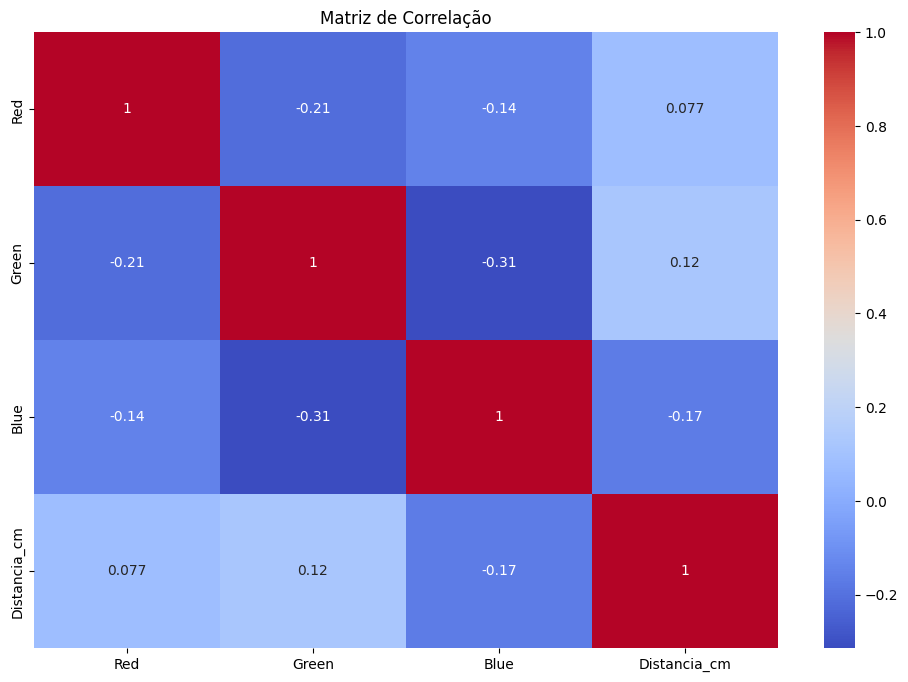

In [9]:
# Heatmap de Correlação entre as features

numeric_df = df.select_dtypes(include=['int64', 'float64'])

numeric_df = numeric_df.drop(columns=['probabilidade_recurso'])

plt.figure(figsize=(12, 8))

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Matriz de Correlação")

plt.show()

### Análise da Matriz de Correlação

Observa-se que as correlações encontradas são relativamente fracas, indicando que as variáveis RGB e a distância apresentam baixa dependência linear entre si.

A maior correlação negativa observada ocorreu entre as variáveis Green e Blue (-0,31), enquanto as demais relações permaneceram próximas de zero.

Esses resultados sugerem que cada sensor fornece informações distintas sobre o ambiente analisado, reduzindo problemas de multicolinearidade e contribuindo para a diversidade dos dados utilizados no treinamento do modelo.



---



### Distribuição da Variável Alvo

O histograma apresenta a distribuição da variável probabilidade_recurso, permitindo observar a frequência de valores baixos, médios e altos no conjunto de dados.

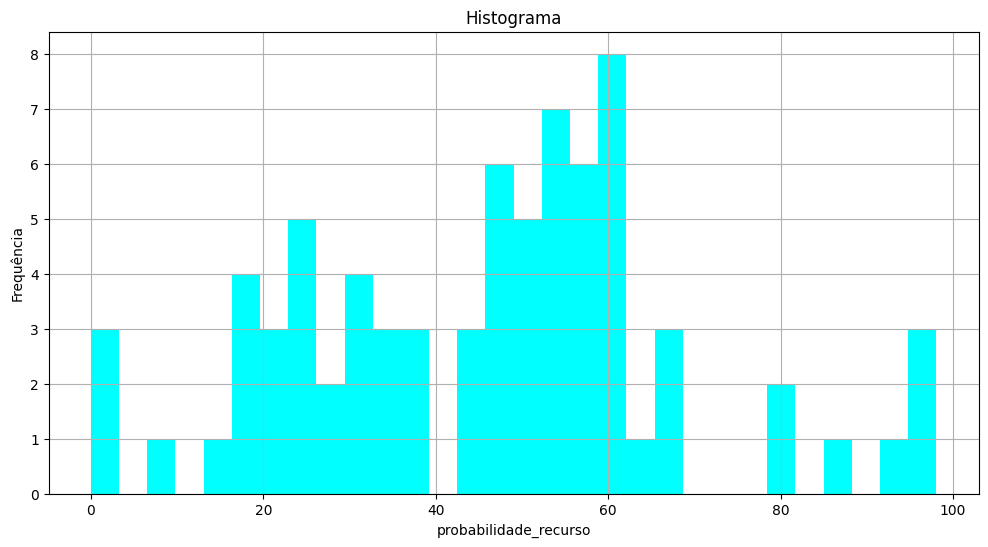

In [10]:
# Histograma da variável alvo (probabilidade_recurso)

# Definindo a área de plotagem
plt.figure(figsize=(12, 6))

# Fixando a inicialização dos números aleatórios
data = df['probabilidade_recurso']

# Criando o histograma
plt.hist(data, bins=30, color='cyan')
plt.xlabel('probabilidade_recurso')
plt.ylabel('Frequência')
plt.title('Histograma')
plt.grid(True)

# Exibindo o gráfico
plt.show()

### Análise da Distribuição da Variável Alvo

Observa-se uma maior concentração de amostras em valores intermediários, principalmente entre 45 e 65, indicando que a maioria das regiões analisadas apresenta potencial moderado para a presença de recursos.

Também são observadas ocorrências em faixas mais baixas e mais altas da escala, demonstrando que o conjunto de dados possui diversidade suficiente para representar diferentes cenários de exploração.

Essa distribuição favorece o treinamento do modelo, permitindo que ele aprenda padrões associados a diferentes níveis de probabilidade de recursos.



---



## Pré-Processamento dos Dados

Antes do treinamento do modelo, foi realizada uma etapa de verificação da qualidade dos dados para identificar possíveis inconsistências que pudessem impactar os resultados.

Inicialmente, foram analisados os valores ausentes (missing values), não sendo encontrados registros nulos em nenhuma das variáveis do conjunto de dados.

Em seguida, foi realizada a verificação de registros duplicados. Foi identificado um registro duplicado, que foi removido para evitar possíveis vieses durante o treinamento do modelo.

Após a limpeza, o conjunto de dados foi considerado adequado para a etapa de modelagem e treinamento da Regressão Linear.


In [11]:
df.isnull().sum()

,0
Red,0
Green,0
Blue,0
Distancia_cm,0
probabilidade_recurso,0


In [12]:
df.duplicated().sum()


np.int64(1)

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.duplicated().sum()

np.int64(0)



---



### Separação das Variáveis

Para o treinamento do modelo, as variáveis de entrada (features) foram separadas da variável alvo (target).

As features utilizadas foram os valores dos sensores RGB e a distância medida pelo rover, enquanto a variável alvo corresponde à probabilidade estimada de encontrar recursos no terreno.

Posteriormente, os dados foram divididos em conjuntos de treinamento e teste para permitir a avaliação do desempenho do modelo em dados não utilizados durante o aprendizado.



In [15]:
# Separando features e labels
x = df.drop('probabilidade_recurso', axis=1)
y = df['probabilidade_recurso']

# Dividindo os dados em conjuntos de treino e teste (70% treino, 30% teste)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)



---



### Aplicação da Regressão Linear

Foi utilizado o algoritmo de Regressão Linear, um modelo supervisionado capaz de identificar relações entre variáveis numéricas e realizar previsões com base em padrões observados nos dados.

O objetivo do modelo é estimar a probabilidade de encontrar recursos em uma determinada região a partir das leituras dos sensores embarcados no rover.


In [16]:
# Selecionando o modelo Regressão Linear
model = LinearRegression()

# Treinando o modelo
model.fit(x_train, y_train)

# Fazendo previsões
y_pred = model.predict(x_test)

# Calculando o coeficiente de determinação (R2)
r2 = model.score(x_test, y_test)




---



## Avaliação do Modelo

Para avaliar o desempenho do modelo foram utilizadas as métricas R² Score e RMSE.

O R² indica o quanto o modelo consegue explicar a variação observada nos dados, enquanto o RMSE mede o erro médio das previsões realizadas.



In [17]:
# R2 Score
r2 = r2_score(y_test, y_pred)
print(f'R² Score: {r2:.2f}')

# RMSE
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f'RMSE: {rmse:.2f}')

R² Score: 0.94
RMSE: 5.42


### Interpretação dos Resultados

Após o processo de limpeza dos dados e remoção de registros duplicados, o modelo de Regressão Linear alcançou um R² de 0,94, indicando que aproximadamente 94% da variação da variável alvo pode ser explicada pelas variáveis utilizadas no treinamento.

Além disso, o RMSE obtido demonstra que o erro médio das previsões permaneceu baixo em relação à escala da variável analisada, sugerindo que o modelo possui boa capacidade preditiva para estimar a probabilidade de recursos em diferentes regiões exploradas pelo rover.



---



## Visualização dos Resultados

O gráfico a seguir compara os valores reais com os valores previstos pelo modelo.

Quanto mais próximos os pontos estiverem da linha ideal, maior a precisão das previsões realizadas pela Regressão Linear.

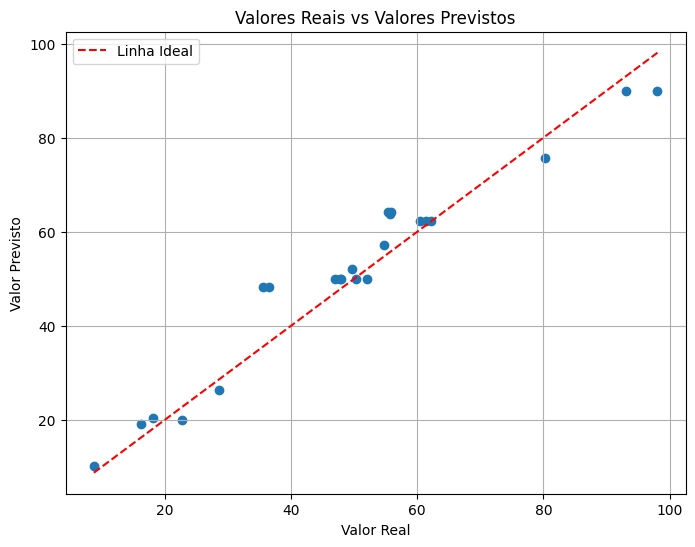

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel('Valor Real')
plt.ylabel('Valor Previsto')
plt.title('Valores Reais vs Valores Previstos')

plt.grid(True)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    label='Linha Ideal'
)

plt.legend()
plt.show()

### Análise do Gráfico

É possível observar que os pontos seguem uma tendência próxima da linha ideal, indicando que as previsões estão próximas dos valores reais. Esse comportamento confirma o bom desempenho do modelo, refletido também pelo R² de 0,94.

Os resultados demonstram que a Regressão Linear conseguiu aprender os padrões presentes nos dados e realizar previsões com boa precisão.



---



## Conclusão

Os resultados obtidos demonstram que o modelo de Regressão Linear foi capaz de identificar padrões relevantes nos dados coletados pelo rover, apresentando desempenho satisfatório na estimativa da probabilidade de recursos.

Como trabalhos futuros, a solução poderá ser integrada aos dados reais coletados pelo ESP32 e disponibilizada em uma aplicação Streamlit para monitoramento e visualização em tempo real das informações da missão.